[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mahdiabolghasemi/Introduction-To-Machine-Learning/blob/DSB102-S2-2026/Workshops/Week3-lab-Soln.ipynb)


# Week 3 — Model Selection & Regularization

**Topics:** Forward stepwise, Ridge, Lasso, cross-validation

---
### Setup — run this cell first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
import warnings; warnings.filterwarnings('ignore')

import os, urllib.request

# Load Hitters baseball salary dataset (ISLR/ISLP classic dataset)
try:
    from ISLP import load_data          # pre-installed on Colab
    df = load_data('Hitters').reset_index(drop=True)
except ImportError:
    if not os.path.exists('Hitters.csv'):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/intro-stat-learning/'
            'ISLP/main/ISLP/data/Hitters.csv',
            'Hitters.csv')
    df = pd.read_csv('Hitters.csv', index_col=0)

df = df.dropna(subset=['Salary'])
df['LogSalary'] = np.log(df['Salary'])
df = pd.get_dummies(df, columns=['League','Division','NewLeague'], drop_first=True, dtype=float)
df = df.drop(columns=['Salary'])

features = [c for c in df.columns if c != 'LogSalary']
X_raw = df[features].values
y     = df['LogSalary'].values

# Scale once for all methods
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0)
print(f"Training: {X_tr.shape}   Test: {X_te.shape}   Features: {features}")

Training: (210, 18)   Test: (53, 18)   Features: ['Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Errors', 'League_N', 'Division_W', 'NewLeague_N']


---
## Part 1 — Forward Stepwise Selection

### 1.1 Tutorial: build a model one predictor at a time

In [2]:
# Tutorial: forward stepwise — select 5 features
lr = LinearRegression()
sfs = SequentialFeatureSelector(lr, n_features_to_select=5, direction='forward', cv=5)
sfs.fit(X_tr, y_tr)
selected = [features[i] for i in sfs.get_support(indices=True)]
print("Top 5 features:", selected)

X_sel_tr = X_tr[:, sfs.get_support()]
X_sel_te = X_te[:, sfs.get_support()]
rmse_fs = np.sqrt(mean_squared_error(y_te, lr.fit(X_sel_tr, y_tr).predict(X_sel_te)))
print(f"Test RMSE (5 features): {rmse_fs:.4f}")

Top 5 features: ['Hits', 'Walks', 'Years', 'CHits', 'CWalks']
Test RMSE (5 features): 0.6674


### 🔧 Exercise 1 — Find the optimal number of features

**Tasks:**
1. Run forward stepwise with `n_features_to_select = 3, 5, 8, 12, 16`.
2. For each, compute 5-fold CV RMSE on the training set.
3. Plot CV RMSE vs number of features. Which gives the minimum?
4. What is the risk of simply maximising R² on the training set?

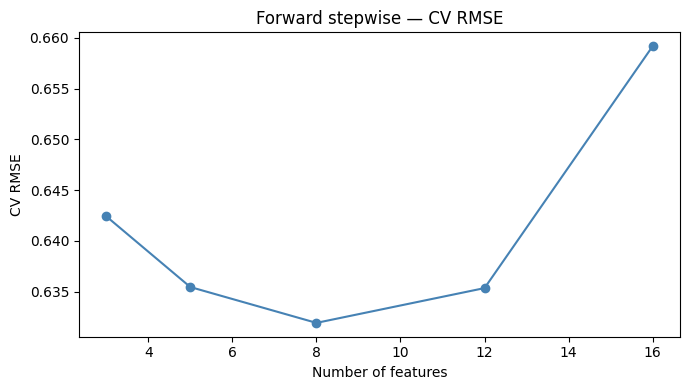

Best k: 8   CV RMSE: 0.6319


In [3]:
# ── SOLUTION Exercise 1 ──────────────────────────────────────────────────────
k_values = [3, 5, 8, 12, 16]
cv_rmses = []
for k in k_values:
    sfs_k = SequentialFeatureSelector(lr, n_features_to_select=k, direction='forward', cv=5)
    sfs_k.fit(X_tr, y_tr)
    X_k = X_tr[:, sfs_k.get_support()]
    scores = cross_val_score(lr, X_k, y_tr, cv=5, scoring='neg_mean_squared_error')
    cv_rmses.append(np.sqrt(-scores.mean()))

plt.figure(figsize=(7, 4))
plt.plot(k_values, cv_rmses, 'o-', color='steelblue')
plt.xlabel('Number of features'); plt.ylabel('CV RMSE')
plt.title('Forward stepwise — CV RMSE')
plt.tight_layout(); plt.show()
print("Best k:", k_values[np.argmin(cv_rmses)],
      "  CV RMSE:", f"{min(cv_rmses):.4f}")

---
## Part 2 — Ridge Regression

### 2.1 Tutorial: coefficient shrinkage paths

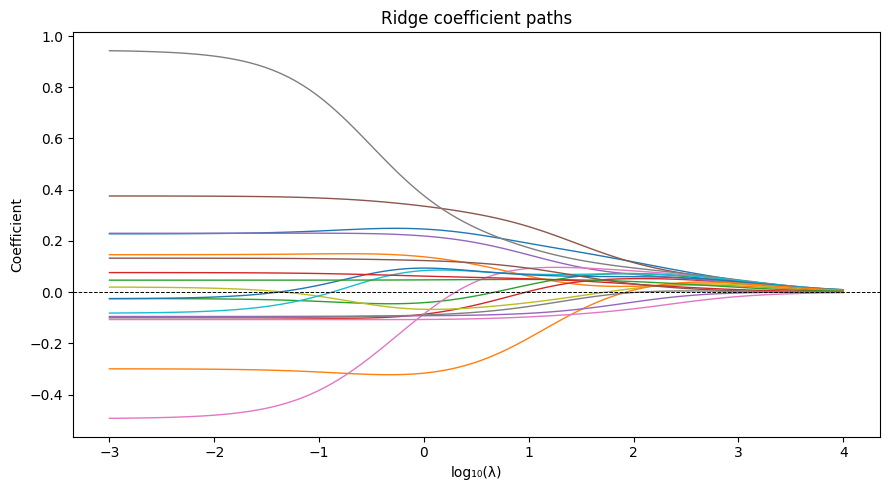

Best λ: 64.2807
Test RMSE (Ridge): 0.6169


In [4]:
# Tutorial: Ridge paths and CV tuning
alphas = np.logspace(-3, 4, 100)
coefs  = np.array([Ridge(alpha=a).fit(X_tr, y_tr).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(9, 5))
for j in range(coefs.shape[1]):
    ax.plot(np.log10(alphas), coefs[:, j], lw=1)
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set(xlabel='log₁₀(λ)', ylabel='Coefficient', title='Ridge coefficient paths')
plt.tight_layout(); plt.show()

ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_tr, y_tr)
print(f"Best λ: {ridge_cv.alpha_:.4f}")
print(f"Test RMSE (Ridge): {np.sqrt(mean_squared_error(y_te, ridge_cv.predict(X_te))):.4f}")

### 🔧 Exercise 2 — Ridge vs OLS

**Tasks:**
1. Fit plain OLS (`LinearRegression`) on the training set. Compute test RMSE.
2. Compare with Ridge (best λ from CV). Which is better?
3. Look at the Ridge coefficient path: do any coefficients reach exactly zero? Why not?
4. When would Ridge be preferred over OLS?

In [5]:
# ── SOLUTION Exercise 2 ──────────────────────────────────────────────────────
ols = LinearRegression().fit(X_tr, y_tr)
rmse_ols   = np.sqrt(mean_squared_error(y_te, ols.predict(X_te)))
rmse_ridge = np.sqrt(mean_squared_error(y_te, ridge_cv.predict(X_te)))
print(f"OLS   test RMSE: {rmse_ols:.4f}")
print(f"Ridge test RMSE: {rmse_ridge:.4f}")
print("Ridge never sets coefficients to exactly zero — it only shrinks them.")
print("Ridge preferred when all predictors have some effect (dense signal).")

OLS   test RMSE: 0.6539
Ridge test RMSE: 0.6169
Ridge never sets coefficients to exactly zero — it only shrinks them.
Ridge preferred when all predictors have some effect (dense signal).


---
## Part 3 — Lasso

### 3.1 Tutorial: sparse solutions

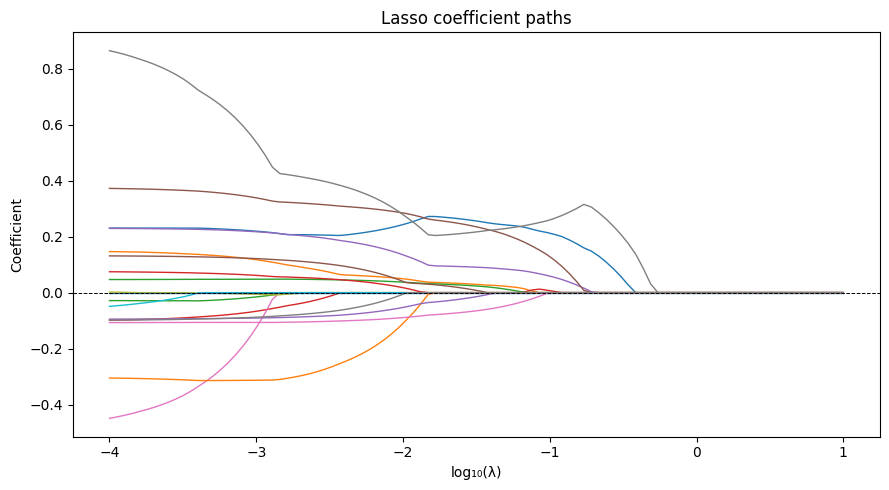

Best λ: 0.0266   Zeroed: 9/18

Non-zero coefficients:
Hits          0.2612
Years         0.2431
CHits         0.2124
Walks         0.0925
Division_W   -0.0694
HmRun         0.0319
PutOuts       0.0263
Errors       -0.0207
League_N      0.0149
dtype: float64


In [6]:
# Tutorial: Lasso paths and CV tuning
lasso_alphas = np.logspace(-4, 1, 100)
lasso_coefs  = np.array([Lasso(alpha=a, max_iter=10000).fit(X_tr, y_tr).coef_
                          for a in lasso_alphas])

fig, ax = plt.subplots(figsize=(9, 5))
for j in range(lasso_coefs.shape[1]):
    ax.plot(np.log10(lasso_alphas), lasso_coefs[:, j], lw=1)
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set(xlabel='log₁₀(λ)', ylabel='Coefficient', title='Lasso coefficient paths')
plt.tight_layout(); plt.show()

lasso_cv = LassoCV(alphas=lasso_alphas, cv=5, max_iter=10000).fit(X_tr, y_tr)
active = pd.Series(lasso_cv.coef_, index=features)
print(f"Best λ: {lasso_cv.alpha_:.4f}   Zeroed: {(active==0).sum()}/{len(features)}")
print("\nNon-zero coefficients:")
print(active[active != 0].sort_values(key=abs, ascending=False).round(4))

### 🔧 Exercise 3 — Lasso variable selection

**Tasks:**
1. Compute test RMSE for Lasso (best λ from CV).
2. Which predictors survive (non-zero coefficients)? Do they match the forward-stepwise selection?
3. Make a side-by-side bar chart: Ridge coefficients vs Lasso coefficients.
4. Why does Lasso perform variable selection but Ridge does not?

Lasso test RMSE: 0.6326


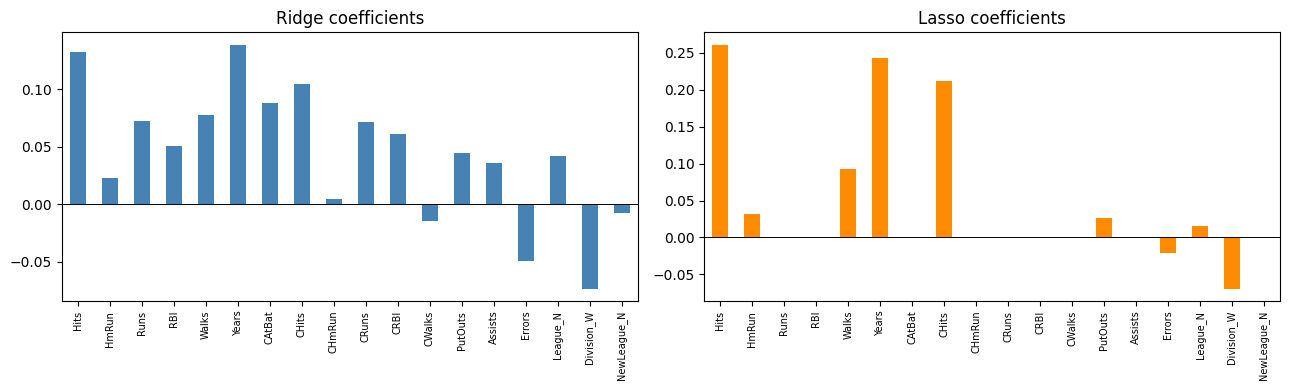

Lasso uses L1 penalty → corner solutions → exact zeros.
Ridge uses L2 penalty → smooth shrinkage, never exact zero.


In [7]:
# ── SOLUTION Exercise 3 ──────────────────────────────────────────────────────
rmse_lasso = np.sqrt(mean_squared_error(y_te, lasso_cv.predict(X_te)))
print(f"Lasso test RMSE: {rmse_lasso:.4f}")

active_lasso = pd.Series(lasso_cv.coef_, index=features)
active_ridge = pd.Series(ridge_cv.coef_, index=features)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
active_ridge.plot(kind='bar', ax=axes[0], color='steelblue', title='Ridge coefficients')
active_lasso.plot(kind='bar', ax=axes[1], color='darkorange', title='Lasso coefficients')
for ax in axes:
    ax.axhline(0, color='k', lw=0.7)
    ax.tick_params(axis='x', labelsize=7)
plt.tight_layout(); plt.show()
print("Lasso uses L1 penalty → corner solutions → exact zeros.")
print("Ridge uses L2 penalty → smooth shrinkage, never exact zero.")

---
## Part 4 — Final Comparison

### 🔧 Exercise 4 — Head-to-head summary

**Tasks:**
1. Fill in this table for your test set:

| Method | Test RMSE |
|---|---|
| OLS (all predictors) | |
| Forward Stepwise (best k) | |
| Ridge (best λ) | |
| Lasso (best λ) | |

2. Which method wins? Is the improvement large?
3. Explain: why do we use the *test* set for final comparison and not CV RMSE?

In [8]:
# ── SOLUTION Exercise 4 ──────────────────────────────────────────────────────
k_best = k_values[np.argmin(cv_rmses)]
sfs_best = SequentialFeatureSelector(lr, n_features_to_select=k_best, direction='forward', cv=5)
sfs_best.fit(X_tr, y_tr)
X_k_te = X_te[:, sfs_best.get_support()]
X_k_tr = X_tr[:, sfs_best.get_support()]
rmse_fs_best = np.sqrt(mean_squared_error(y_te, lr.fit(X_k_tr, y_tr).predict(X_k_te)))

results = {
    'OLS':            rmse_ols,
    f'Forward ({k_best} feats)': rmse_fs_best,
    'Ridge':          rmse_ridge,
    'Lasso':          rmse_lasso,
}
for m, r in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {m:25s}  RMSE = {r:.4f}")

  Ridge                      RMSE = 0.6169
  Lasso                      RMSE = 0.6326
  OLS                        RMSE = 0.6539
  Forward (8 feats)          RMSE = 0.6564


---
## Summary

| Method | Shrinks? | Selects? | Best when |
|---|---|---|---|
| **OLS** | No | No | p << n, all predictors needed |
| **Best subset / Stepwise** | No | Yes | Small p |
| **Ridge** | Yes | No | Many predictors, all relevant |
| **Lasso** | Yes | Yes | Sparse signal; need interpretation |